## 03 - Model selection

The shape of the problem is **sequence-to-scalar regression with very small N**:
- 100 experiments → 100 modeling rows.
- Each row is a multivariate trajectory (4 `W:` inputs, 6 `X:` measurements over 7–14 days) plus 13 `Z:` design constants.
- The label is one scalar per experiment (final titer), reported on the last day.

This rules out several model families that are sometimes reflexively reached for on time-stamped data:

**Univariate time-series forecasters (Prophet, ARIMA / SARIMA, ETS): wrong problem shape.**
These predict future values of the *same* series given its past. We are not forecasting a continuation of titer; we are predicting one terminal scalar from a designed multivariate run.

**Deep sequence models (LSTM, GRU, Transformer, TCN): too data-hungry.**
N = 100 with 7–14 timesteps is two orders of magnitude below where these models become competitive.

**What does fit:** classical regression on per-experiment summary features.
- **PLS** handles colinearity among process variables
- **Regularized linear models** (like Ridge) - stable and interpretable at this sample size.
- **Non-linear models** (SVR-RBF, gradient boosting, Random Forest) - capture the nonlinearity in growth/feed/titer dynamics without needing thousands of rows.

## Modeling baselines

We collapse each experiment's time-series into a fixed-size feature vector and then run a few baselines against `log Y:Titer` with 5-fold CV.

**Per-experiment feature matrix**
- All 13 `Z:` setpoints as-is.
- Per `W:` variable: total over the run (`sum`) and mean.
- Per `X:` variable: final value, max, mean, area under curve (AUC), and slope.

**Three nested baselines (each on `log Y:Titer`, 5-fold CV, RMSE & R²)**
1. Ridge on **`X:VCD` mean only**: the one-feature found in the previous notebook
2. Ridge on **`Z:` setpoints only**: what's predictable from the experimental design alone (no trajectory).
3. Ridge / XGBoost on the **full feature matrix**: what the trajectory adds on top.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
train_data_path = "../data/datahow_interview_train_data.csv"
train_targets_data_path = "../data/datahow_interview_train_targets.csv"

In [4]:
train_df = pd.read_csv(train_data_path)
targets_df = pd.read_csv(train_targets_data_path)

In [5]:
# Drop RowID column
train_df = train_df.drop(columns="RowID")
targets_df = targets_df.drop(columns="RowID")

In [6]:
df = pd.merge(train_df, targets_df, how="outer", on=["Exp", "Time[day]"])

In [ ]:
titer_by_exp = df.dropna(subset=["Y:Titer"]).set_index("Exp")["Y:Titer"]
setpoints_cols = [col for col in train_df.columns if col.startswith("Z:")]

In [8]:
def build_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse each experiment's time-series into one row of features."""
    z_cols = [col for col in train_df.columns if col.startswith("Z:")]
    w_cols = [c for c in df.columns if c.startswith("W:")]
    x_cols = [c for c in df.columns if c.startswith("X:")]

    rows = []
    for exp, exp_df in df.groupby("Exp"):
        exp_df = exp_df.sort_values("Time[day]")
        time = exp_df["Time[day]"].values
        day0 = exp_df.loc[exp_df["Time[day]"] == 0].iloc[0]

        row = {"Exp": exp}
        for col in z_cols:
            row[col] = day0[col]
        for col in w_cols:
            row[f"{col}_sum"] = exp_df[col].sum()
            row[f"{col}_mean"] = exp_df[col].mean()
        for col in x_cols:
            series = exp_df[col].values
            row[f"{col}_final"] = series[-1]
            row[f"{col}_max"] = series.max()
            row[f"{col}_mean"] = series.mean()
            row[f"{col}_auc"] = np.trapezoid(series, time)

            # Growth-phase features replace the linear _slope: split the curve
            # at its peak and report rise/fall rates separately. Captures the
            # exponential-then-decline shape of VCD/Glc/Lac better than a single
            # whole-run slope.
            peak_idx = int(np.argmax(series))
            peak_day = time[peak_idx]
            last_day = time[-1]
            row[f"{col}_peak_day"] = peak_day
            row[f"{col}_growth_rate"] = (
                (series[peak_idx] - series[0]) / peak_day if peak_day > 0 else 0.0
            )
            row[f"{col}_decline_rate"] = (
                (series[-1] - series[peak_idx]) / (last_day - peak_day)
                if last_day > peak_day else 0.0
            )
        rows.append(row)

    return pd.DataFrame(rows).set_index("Exp")


X_features = build_feature_matrix(df)
y = np.log(titer_by_exp.loc[X_features.index])
print(f"Feature matrix: {X_features.shape}, target: {y.shape}")

X_features.head()

Feature matrix: (100, 63), target: (100,)


,Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,Z:tempShift,Z:Stir,Z:DO,Z:ExpDuration,W:temp_sum,W:temp_mean,W:pH_sum,W:pH_mean,W:FeedGlc_sum,W:FeedGlc_mean,W:FeedGln_sum,W:FeedGln_mean,X:VCD_final,X:VCD_max,X:VCD_mean,X:VCD_auc,X:VCD_peak_day,X:VCD_growth_rate,X:VCD_decline_rate,X:Glc_final,X:Glc_max,X:Glc_mean,X:Glc_auc,X:Glc_peak_day,X:Glc_growth_rate,X:Glc_decline_rate,X:Gln_final,X:Gln_max,X:Gln_mean,X:Gln_auc,X:Gln_peak_day,X:Gln_growth_rate,X:Gln_decline_rate,X:Amm_final,X:Amm_max,X:Amm_mean,X:Amm_auc,X:Amm_peak_day,X:Amm_growth_rate,X:Amm_decline_rate,X:Lac_final,X:Lac_max,X:Lac_mean,X:Lac_auc,X:Lac_peak_day,X:Lac_growth_rate,X:Lac_decline_rate,X:Lysed_final,X:Lysed_max,X:Lysed_mean,X:Lysed_auc,X:Lysed_peak_day,X:Lysed_growth_rate,X:Lysed_decline_rate
Exp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Exp 1,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,13.0,224.242424,43.383838,10.0,410.111111,37.282828,74.232323,6.748393,45.252525,4.113866,54.545455,4.958678,36.988184,36.988184,19.830846,198.803887,10,3.530554,0.000000,14.657896,14.657896,8.437089,84.052505,10,1.180485,0.000000,0.073529,6.005418,1.699388,15.653790,0,0.000000,-0.593189,4.063493,4.063493,2.061484,20.594577,10,0.396349,0.000000,4.828035,5.821098,3.947288,40.956149,5,1.144220,-0.198613,0.282538,0.282538,0.059261,0.510602,10,0.028254,0.0
Exp 10,2.0,12.0,3.272727,7.767677,6.949495,6.722222,13.0,37.888889,36.343434,10.0,162.626263,70.656566,14.0,560.606061,37.373737,103.787879,6.919192,32.727273,2.181818,77.676768,5.178451,0.007129,6.033812,2.603597,38.763094,7,0.779889,-0.860955,31.884174,31.884174,17.745714,247.521262,14,1.888533,0.000000,56.545510,62.089637,31.707383,444.712203,12,4.736504,-2.772063,13.744255,13.744255,5.009491,68.220241,14,0.974590,0.000000,6.120684,6.349503,4.118153,58.661950,12,0.520792,-0.114409,0.234443,0.234443,0.057955,0.752101,14,0.016746,0.0
Exp 100,2.0,11.0,4.000000,7.000000,7.000000,6.500000,10.0,37.000000,36.000000,10.0,200.000000,55.000000,7.0,296.000000,37.000000,56.000000,7.000000,24.000000,3.000000,42.000000,5.250000,30.811184,30.811184,14.482421,99.924172,7,4.250282,0.000000,3.046361,5.673068,3.479897,24.631229,5,0.460706,-1.313353,0.000000,4.914079,1.115279,6.465194,0,0.000000,-0.702011,2.693214,2.693214,1.369552,9.559807,7,0.370459,0.000000,2.964407,4.436968,2.878758,21.497857,3,1.445656,-0.368140,0.040306,0.040306,0.011029,0.068078,7,0.005758,0.0
Exp 11,2.0,13.0,2.868687,7.565657,7.484848,6.550505,10.0,37.626263,36.949495,11.0,205.050505,52.979798,10.0,413.888889,37.626263,81.398990,7.399908,25.818182,2.347107,68.090909,6.190083,16.088636,16.955638,10.778701,109.571635,8,1.882016,-0.433501,11.645204,11.774292,8.486037,84.388997,9,0.611631,-0.129088,28.154761,28.154761,13.781960,134.891311,10,2.288901,0.000000,5.973805,5.973805,2.344082,22.747998,10,0.587381,0.000000,5.324528,5.411867,3.943503,40.666265,5,1.062373,-0.017468,0.124563,0.124563,0.029964,0.267324,10,0.012456,0.0
Exp 12,1.0,11.0,4.565657,6.373737,6.565657,6.217172,13.0,37.101010,35.252525,9.0,207.070707,74.191919,14.0,545.424242,36.361616,97.787879,6.519192,45.656566,3.043771,63.737374,4.249158,22.611620,24.141573,15.609570,221.989951,13,1.726614,-1.529953,14.064906,22.161997,14.045000,202.180735,11,1.748942,-2.699030,1.161572,16.683513,10.573258,155.305488,11,1.023483,-5.173980,7.949605,7.961859,4.031273,56.444289,13,0.604758,-0.012253,4.859272,6.956316,5.018960,72.804757,11,0.623301,-0.699014,0.525695,0.525695,0.149658,1.982019,14,0.037550,0.0


In [ ]:
import warnings

from lightgbm import LGBMRegressor
from scipy.stats import loguniform, randint, uniform
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")


N_SEEDS = 5
INNER_CV_SEED = 0
inner_cv = KFold(n_splits=5, shuffle=True, random_state=INNER_CV_SEED)


def nested_cv(
    name: str,
    model,
    param_grid: dict,
    features: pd.DataFrame,
    n_seeds: int = N_SEEDS,
    n_iter: int | None = None,
) -> None:
    """Repeated nested CV. If `n_iter` is given, the inner search is
    RandomizedSearchCV (n_iter samples per outer seed); otherwise it's
    GridSearchCV. Outer 5-fold is repeated across n_seeds; metrics are
    aggregated across all n_seeds x 5 fold-level estimates."""
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe_grid = {f"model__{k}": v for k, v in param_grid.items()}

    rmse_all, r2_all = [], []
    for seed in range(n_seeds):
        outer_cv = KFold(n_splits=5, shuffle=True, random_state=seed)
        if n_iter is None:
            search = GridSearchCV(
                pipe, pipe_grid, cv=inner_cv,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1,
            )
        else:
            search = RandomizedSearchCV(
                pipe, pipe_grid, n_iter=n_iter, cv=inner_cv,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1, random_state=seed,
            )
        res = cross_validate(
            search, features, y, cv=outer_cv,
            scoring=["neg_root_mean_squared_error", "r2"],
        )
        rmse_all.append(-res["test_neg_root_mean_squared_error"])
        r2_all.append(res["test_r2"])

    rmse_all = np.concatenate(rmse_all)
    r2_all = np.concatenate(r2_all)
    print(
        f"{name:42s}  RMSE = {rmse_all.mean():.3f} ± {rmse_all.std():.3f}"
        f"   R² = {r2_all.mean():.3f} ± {r2_all.std():.3f}"
        f"   (n={len(rmse_all)})"
    )


# Ridge baselines
ridge_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
nested_cv("Ridge - mean X:VCD only", Ridge(), ridge_grid, X_features[["X:VCD_mean"]])
nested_cv("Ridge - Z: setpoints only", Ridge(), ridge_grid, X_features[setpoints_cols])
nested_cv("Ridge - full feature matrix", Ridge(), ridge_grid, X_features)

# SVR
svr_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "epsilon": [0.01, 0.1],
}
nested_cv("SVR (RBF) - full feature matrix", SVR(kernel="rbf"), svr_grid, X_features)

# Tree models: wider distributions with RandomizedSearchCV (n_iter=40 per outer seed)
rf_dist = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.5, 1.0],
}
nested_cv(
    "Random Forest - full feature matrix",
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_dist,
    X_features,
    n_iter=40,
)

xgb_dist = {
    "n_estimators": [100, 300, 500],
    "learning_rate": loguniform(0.01, 0.3),
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "reg_lambda": loguniform(0.01, 100),
    "reg_alpha": loguniform(0.0001, 10),
}
nested_cv(
    "XGBoost - full feature matrix",
    XGBRegressor(random_state=42, n_jobs=1),
    xgb_dist,
    X_features,
    n_iter=40,
)

lgbm_dist = {
    "n_estimators": [100, 300, 500],
    "learning_rate": loguniform(0.01, 0.3),
    "max_depth": [3, 4, 5, 6, 8],
    "num_leaves": randint(8, 64),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_samples": randint(3, 20),
    "reg_lambda": loguniform(0.01, 100),
    "reg_alpha": loguniform(0.0001, 10),
}
nested_cv(
    "LightGBM - full feature matrix",
    LGBMRegressor(random_state=42, n_jobs=1, verbose=-1),
    lgbm_dist,
    X_features,
    n_iter=40,
)

### Findings

**1. Ridge on the full feature matrix is the leader.** RMSE **0.149 ± 0.035**, R² **0.904 ± 0.053**. Non-linear models (SVR, RF, XGBoost, LightGBM) are within noise or slightly worse, and all carry wider std. At N=100 the bias-variance tradeoff favors the most regularized model.

**2. The trajectory carries almost all the signal.** Z-only Ridge gets R² 0.25; full-matrix Ridge gets 0.90. The recipe alone explains a quarter of the variance, what actually happens during the run explains the rest.

**3. A single time-integrated trajectory summary (`X:VCD_mean`) beats all 13 design parameters combined**. VCD-mean-only R² 0.40 vs Z-only R² 0.25. Bioprocess outcomes are dominated by *what happened* during the run, not by *what was planned*. Mean VCD captures the total integrated producer-cell exposure across the whole experiment, which is more informative than any single design parameter. The model isn't learning recipe → titer, it's reading the time-integrated cell-density signal and refining it into a calibrated titer estimate.

## Stronger feature-based baseline

Let's extend the previous baseline with:

1. **PLS**: Handles colinearity natively (every `X:` summary correlates with the others) and produces interpretable loadings/scores domain reviewers expect. We tune `n_components` on the inner fold.

2. **Two missing ablations** to clean up the Z / W / X signal decomposition:
   - **`X:` trajectory only**: does the model still work if recipe (`Z`) and process inputs (`W`) are removed? Tests whether observed dynamics alone carry the signal.
   - **`Z + W` only (no observed dynamics)**: what's predictable without seeing how the run unfolded? Tests whether the design plus the executed input schedule is enough.

Together with the existing tiers (mean-VCD-only, Z-only, full), this gives a breakdown of where the predictive signal lives.

In [ ]:
from sklearn.cross_decomposition import PLSRegression

w_cols_full = [c for c in X_features.columns if c.startswith("W:")]
x_cols_full = [c for c in X_features.columns if c.startswith("X:")]

# Ablations on Ridge to decompose the signal across Z / W / X
nested_cv(
    "Ridge - X: trajectory only",
    Ridge(),
    ridge_grid,
    X_features[x_cols_full],
)
nested_cv(
    "Ridge - Z + W (no observed dynamics)",
    Ridge(),
    ridge_grid,
    X_features[setpoints_cols + w_cols_full],
)

# PLS
pls_grid = {"n_components": list(range(1, 16))}
nested_cv(
    "PLS - full feature matrix",
    PLSRegression(scale=False),
    pls_grid,
    X_features,
)

### Leaderboard

| Model | RMSE | R² |
|---|---|---|
| Ridge - VCD-mean only | 0.382 ± 0.054 | 0.397 |
| Ridge - Z only | 0.430 ± 0.082 | 0.253 |
| Ridge - Z + W (no observed dynamics) | 0.416 ± 0.074 | 0.291 |
| Ridge - X only (trajectory) | 0.167 ± 0.047 | 0.880 |
| **Ridge - full** | **0.149 ± 0.035** | **0.904** |
| PLS - full | 0.160 ± 0.034 | 0.892 |
| XGBoost - full | 0.163 ± 0.039 | 0.890 |
| LightGBM - full | 0.170 ± 0.037 | 0.881 |
| Random Forest - full | 0.189 ± 0.048 | 0.855 |
| SVR (RBF) - full | 0.195 ± 0.064 | 0.835 |

**Findings:**

**1. `W:` aggregates are essentially redundant with `Z:`.** Z+W gains only +0.04 R² over Z alone (0.291 vs 0.253). Mechanistically expected. `W:FeedGlc_sum ≈ Z:FeedRateGlc × feed-window length`, so our `_sum`/`_mean` aggregates of W are largely deterministic functions of Z.

**2. `X:` alone gets within 2 R² of the full matrix.** X-only 0.880; full 0.904. The trajectory absorbs almost all the predictive signal - including the indirect effects of Z and W that already played out through the dynamics. Adding `(Z, W)` on top of `X` buys only +0.024 R². (Growth-phase features narrowed this gap from the original +0.045.)

**3. PLS ≈ Ridge.** 0.892 vs 0.904: within sampling noise. PLS validates that Ridge isn't lucky on this particular feature design, the bioprocess-standard linear method gives the same answer. The equivalence also implies our feature matrix is effectively low-rank (correlated `X:` summaries), which is why PLS's low-rank constraint doesn't help and Ridge's L2 shrinkage lands on the same place.

**4. wider tree search + growth-phase features had no impact on the leaderboard.** RandomizedSearchCV with broader distributions for RF / XGB / LGBM / SVR did not close the gap to Ridge, slightly widened it for SVR and LightGBM. Growth-phase X features marginally improved Ridge full (0.153 → 0.149) and X-only (0.185 → 0.167) but didn't change the qualitative story. Their value is in interpretability (`peak_day` reads better than `VCD_slope`), not RMSE.

## Outputs

The Ridge full-feature model wins the leaderboard at RMSE 0.149, R² 0.904.  

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_predict

def make_ridge_pipe():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100])),
    ])

### Coefficient inspection

We fit Ridge on the full feature matrix (with α chosen by `RidgeCV`) and inspect the top-20 features by |coefficient|.

Selected α: 1.0000


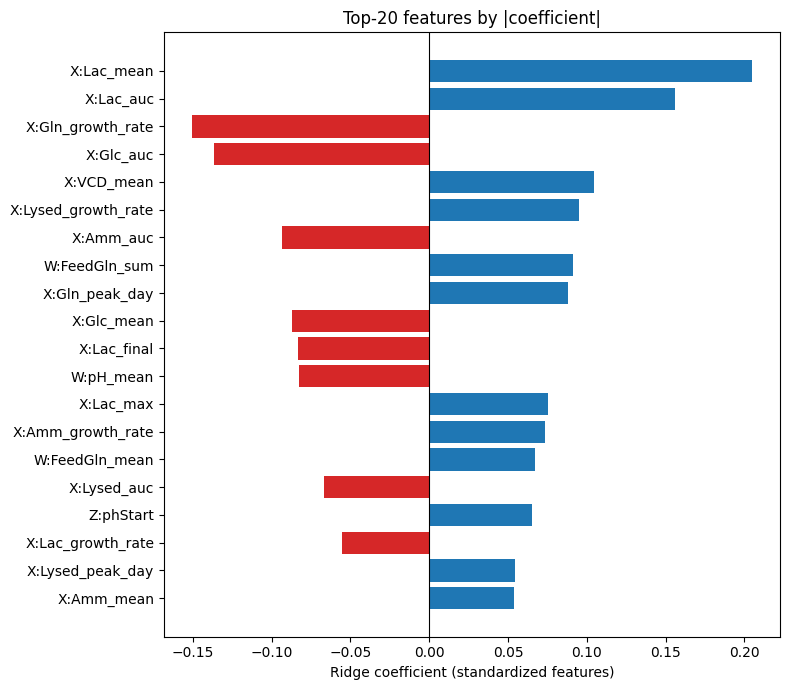

In [17]:
final_ridge = make_ridge_pipe().fit(X_features, y)
ridge_step = final_ridge.named_steps["model"]
print(f"Selected α: {ridge_step.alpha_:.4f}")

coefs = pd.Series(ridge_step.coef_, index=X_features.columns)
top20 = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["tab:red" if c < 0 else "tab:blue" for c in top20[::-1].values]
ax.barh(range(len(top20)), top20[::-1].values, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Ridge coefficient (standardized features)")
ax.set_title("Top-20 features by |coefficient|")
plt.tight_layout()

- **`X:Lac_mean` outranks `X:VCD_mean` (#1 vs #5)**, despite VCD-mean being the strongest *univariate* correlate per the plots notebook. Multivariate Ridge can substitute features that carry overlapping information, and lactate is mechanistically downstream of VCD (more cells → more lactate via glycolysis); Lac_mean integrates more state than VCD alone, so once both are in the model Ridge shifts weight to the more-informative aggregate. Univariate champions don't always win the multivariate fight.
- **`X:Lysed_growth_rate` is positive (+0.10).** Counterintuitive: faster lysis should mean less product. Most likely explanation: **product release** from lysed cells dumping intracellular mAb into the medium. Worth a domain-interpretation conversation, not a model bug.

###  Residuals

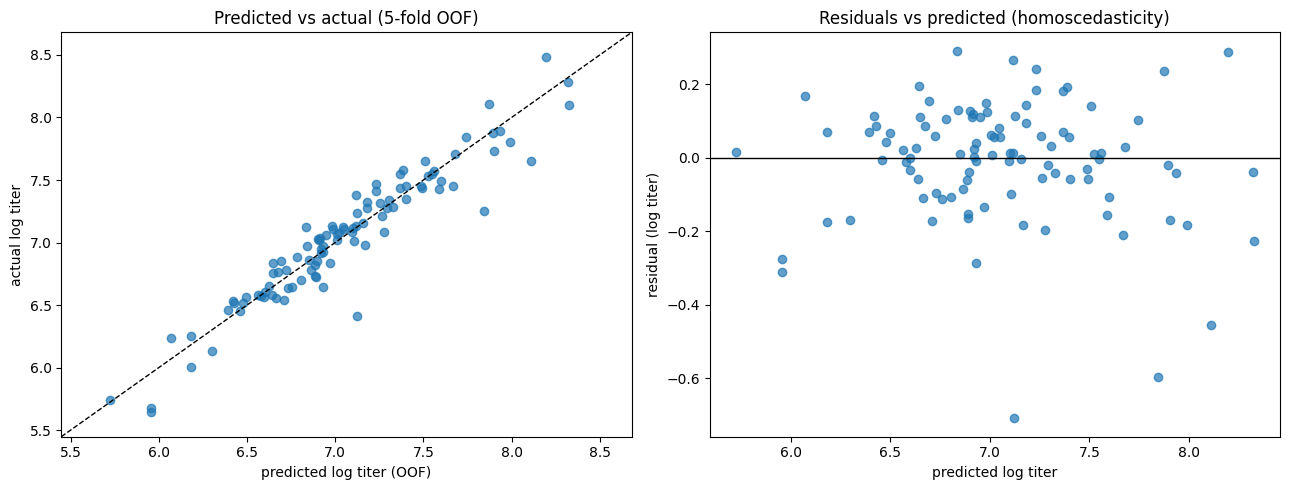

In [18]:
inner_cv_diag = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred = cross_val_predict(make_ridge_pipe(), X_features, y, cv=inner_cv_diag)
oof_resid = y.values - oof_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Predicted vs actual
axes[0].scatter(oof_pred, y.values, alpha=0.7)
lims = [y.min() - 0.2, y.max() + 0.2]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel("predicted log titer (OOF)")
axes[0].set_ylabel("actual log titer")
axes[0].set_title("Predicted vs actual (5-fold OOF)")

# 2. Residuals vs predicted (homoscedasticity check)
axes[1].scatter(oof_pred, oof_resid, alpha=0.7)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("predicted log titer")
axes[1].set_ylabel("residual (log titer)")
axes[1].set_title("Residuals vs predicted (homoscedasticity)")

plt.tight_layout()
plt.show()

**Residuals check** 
- Predicted-vs-actual hugs the diagonal  
- residuals-vs-predicted is a random cloud (homoscedastic - confirms previous analysis).